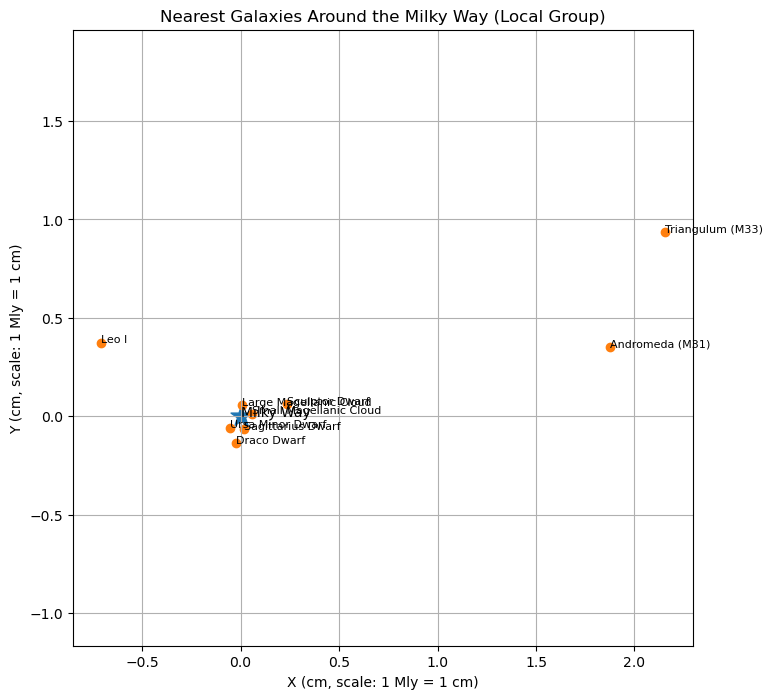

In [1]:
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
import numpy as np

# -------------------------------
# 1. Local Group galaxies (~10)
# -------------------------------
names = [
    "Milky Way", "Andromeda (M31)", "Triangulum (M33)",
    "Large Magellanic Cloud", "Small Magellanic Cloud",
    "Sagittarius Dwarf", "Ursa Minor Dwarf",
    "Draco Dwarf", "Sculptor Dwarf", "Leo I"
]

# RA (deg), Dec (deg), Distance (million light years)
ra = [0, 10.6847, 23.4621, 80.8939, 13.1867, 283.7636, 227.2854, 260.0517, 15.0392, 152.1229]
dec = [0, 41.2692, 30.6602, -69.7561, -72.8286, -30.4783, 67.2225, 57.9153, -33.7090, 12.3130]

distance_mly = [
    0.0, 2.54, 2.73,
    0.163, 0.200,
    0.078, 0.205,
    0.260, 0.290, 0.820
]

# -------------------------------
# 2. Create SkyCoord
# -------------------------------
coords = SkyCoord(
    ra=ra * u.degree,
    dec=dec * u.degree,
    distance=distance_mly * u.Mlyr
)

# -------------------------------
# 3. Convert to Cartesian
# -------------------------------
cartesian = coords.cartesian

x = cartesian.x.to(u.Mlyr).value
y = cartesian.y.to(u.Mlyr).value

# -------------------------------
# 4. Scale: 1 Mly = 1 cm
# -------------------------------
x_scaled = x
y_scaled = y

# -------------------------------
# 5. Plot
# -------------------------------
plt.figure(figsize=(8, 8))

# Milky Way at center
plt.scatter(0, 0, marker='*', s=250)
plt.text(0, 0, "Milky Way", fontsize=10)

# Other galaxies
plt.scatter(x_scaled[1:], y_scaled[1:])

# Labels
for i in range(1, len(names)):
    plt.text(x_scaled[i], y_scaled[i], names[i], fontsize=8)

plt.xlabel("X (cm, scale: 1 Mly = 1 cm)")
plt.ylabel("Y (cm, scale: 1 Mly = 1 cm)")
plt.title("Nearest Galaxies Around the Milky Way (Local Group)")

plt.grid()
plt.axis('equal')

plt.show()